In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -r "/content/drive/MyDrive/GEO_AI_Cropland_Mapping_Challenge/requirements.txt"

In [3]:
import pandas as pd
import numpy as np
import random
from pathlib import Path
import os
import warnings
import time
import geopandas as gpd
from typing import Optional, List, Sequence, Dict, Any,Tuple
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [4]:
#log time
starttime = time.time()

In [5]:
#reproducability
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [6]:
DATA_PATH = "/content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/"

In [7]:
raw_data_path = DATA_PATH + "raw_train_data/"
fergana_gdf = gpd.read_file(raw_data_path + "Fergana_training_samples.shp")
if fergana_gdf.crs is None:
    fergana_gdf = fergana_gdf.set_crs("EPSG:4326")

orenburg_gdf = gpd.read_file(raw_data_path + "Orenburg_training_samples.shp")
if orenburg_gdf.crs is None:
    orenburg_gdf = orenburg_gdf.set_crs("EPSG:4326")

In [8]:
fergana_gdf['region'] = 'Fergana'
orenburg_gdf['region'] = 'Orenburg'

target_ids = pd.concat([fergana_gdf,orenburg_gdf],axis=0)
target_ids.head()

,ID,Cropland,geometry,region
0,1,0,POINT (71.74908 41.39632),Fergana
1,2,0,POINT (72.90143 41.07219),Fergana
2,3,1,POINT (72.46399 40.61906),Fergana
3,4,0,POINT (72.19732 41.62759),Fergana
4,5,0,POINT (71.31204 41.36946),Fergana


In [9]:

#To obtain the exact results on the chosen model we use  the data that had already been extracted
S1_DIR = Path(DATA_PATH  + "EE_exports_S1_presaved")
S2_DIR = Path(DATA_PATH  + "EE_exports_S2_presaved")

#otherwise any newly extracted data gets saved in these folders thus uncomemmnt to use
# S1_DIR = Path(DATA_PATH  + "EE_S1_Exports")
# S2_DIR = Path(DATA_PATH  + "EE_S2_Exports")

In [10]:
# File name patterns used by the export scripts
S1_PATTERNS = [
    "train_S1_Fergana_chunk_*.csv",
    "train_S1_Orenburg_chunk_*.csv",
    "train_S1_fergana_chunk_*.csv",
    "train_S1_orenburg_chunk_*.csv",
]
S2_PATTERNS = [
    "train_S2_Fergana_chunk_*.csv",
    "train_S2_Orenburg_chunk_*.csv",
    "train_S2_fergana_chunk_*.csv",
    "train_S2_orenburg_chunk_*.csv",
]

In [11]:
#columns from the extracted dataset
S1_COLS = ['ID','VH','VV','date','orbit','polarization','rel_orbit','region']
S2_COLS = ['B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A','ID','cloud_pct','date','solar_azimuth','solar_zenith','region']


In [12]:
def load_and_stack(dir_path, patterns, required_cols, key_cols=('ID','date','region')):
    """
    Load all matching CSVs from dir_path using the glob patterns,
    align to required_cols (adding missing ones as NA), stack, de-duplicate, and sort.
    - dir_path: str or Path to folder
    - patterns: list of glob patterns (e.g., ["train_S1_fergana_chunk_*.csv", "train_S1_orenburg_chunk_*.csv"])
    - required_cols: final column order to enforce
    - key_cols: columns used to drop duplicate rows (default ['ID','date','region'])
    """
    dir_path = Path(dir_path)

    matched_files = []
    frames = []

    for patt in patterns:
        files = sorted(dir_path.glob(patt))
        matched_files.extend(files)
        for f in files:
            df = pd.read_csv(f, dtype={'ID': str, 'region': str}, low_memory=False)
            print(f"[read] {f}  rows={len(df)}")

            # normalize date if present
            if 'date' in df.columns:
                df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d')

            # ensure every required column exists
            for c in required_cols:
                if c not in df.columns:
                    df[c] = pd.NA

            # enforce order & subset
            df = df[required_cols]
            frames.append(df)

    if not matched_files:
        contents = [p.name for p in dir_path.glob("*")]
        raise FileNotFoundError(f"No CSVs found in {dir_path} for patterns {patterns}. "
                                f"Directory contents: {contents[:12]}{' ...' if len(contents)>12 else ''}")

    # stack
    out = pd.concat(frames, ignore_index=True)

    # drop duplicates on keys (only if those cols exist)
    subset = [k for k in key_cols if k in out.columns]
    if subset:
        out = out.drop_duplicates(subset=subset).reset_index(drop=True)

    # sort nicely
    sort_cols = [c for c in ('region','ID','date') if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    return out

In [13]:
def main():
    # Merge S1 chunks
    s1 = load_and_stack(S1_DIR, S1_PATTERNS, S1_COLS, key_cols=['ID','date','region'])
    s1.to_csv(raw_data_path + "train_S1.csv", index=False)
    print(f"Wrote train_S1.csv  | rows={len(s1):,}  ids={s1['ID'].nunique():,}  dates={s1['date'].nunique():,}")

    # Merge S2 chunks
    s2 = load_and_stack(S2_DIR, S2_PATTERNS, S2_COLS, key_cols=['ID','date','region'])
    s2.to_csv(raw_data_path + "train_S2.csv", index=False)
    print(f"Wrote train_S2.csv  | rows={len(s2):,}  ids={s2['ID'].nunique():,}  dates={s2['date'].nunique():,}")
    return s1,s2

In [14]:
if __name__ == "__main__":
    s1_train,s2_train = main()

[read] /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/EE_exports_S1_presaved/train_S1_fergana_chunk_001.csv  rows=2912
[read] /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/EE_exports_S1_presaved/train_S1_fergana_chunk_002.csv  rows=2911
[read] /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/EE_exports_S1_presaved/train_S1_fergana_chunk_003.csv  rows=2909
[read] /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/EE_exports_S1_presaved/train_S1_fergana_chunk_004.csv  rows=2912
[read] /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/EE_exports_S1_presaved/train_S1_fergana_chunk_005.csv  rows=2910
[read] /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/EE_exports_S1_presaved/train_S1_fergana_chunk_006.csv  rows=2911
[read] /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/EE_exports_S1_presaved/train_S1_fergana_chunk_007.csv  rows=2912
[read] /content/drive/MyDri

In [15]:
s2_train.head()

,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,ID,cloud_pct,date,solar_azimuth,solar_zenith,region
0,2677,1702,337,515,601,1386,2602,3123,3370,3499,1,1.819191,2021-07-01,141.441624,21.589545,Fergana
1,2677,1702,337,515,601,1386,2602,3123,3370,3499,1,1.819191,2021-07-02,141.441624,21.589545,Fergana
2,2853,1980,440,751,725,1425,2520,3051,3204,3345,1,0.719796,2021-07-04,141.488570,22.039166,Fergana
3,2853,1980,440,751,725,1425,2520,3051,3204,3345,1,0.719796,2021-07-05,141.488570,22.039166,Fergana
4,2853,1980,440,751,725,1425,2520,3051,3204,3345,1,0.719796,2021-07-07,141.488570,22.039166,Fergana


In [16]:
s1_train.head()

,ID,VH,VV,date,orbit,polarization,rel_orbit,region
0,1,-21.368883,-11.002121,2021-07-01,DESCENDING,"[VV, VH]",5.0,Fergana
1,1,-14.244027,-9.720287,2021-07-06,DESCENDING,"[VV, VH]",78.0,Fergana
2,1,-15.528642,-6.461014,2021-07-13,DESCENDING,"[VV, VH]",5.0,Fergana
3,1,-20.782069,-9.445640,2021-07-18,DESCENDING,"[VV, VH]",78.0,Fergana
4,1,-15.992340,-11.147478,2021-07-30,DESCENDING,"[VV, VH]",78.0,Fergana


## **RETRIEVE TRAIN IDS WITH DATA PRESENT IN THE TEST FILES DATA FROM SENTINEL**

In [17]:
TEST_DIR_PATH = DATA_PATH + "raw_test_data/"

In [18]:
test_ids = pd.read_csv(TEST_DIR_PATH + 'Test.csv')

In [19]:
test_ids.columns = ['ID','region','lat','lon']
test_ids = test_ids[['ID','region']]

In [20]:
s1_test = pd.read_csv(TEST_DIR_PATH + 'Sentinel1.csv')
s1_test = s1_test.merge(test_ids,on='ID',how='left')

In [21]:
s2_test = pd.read_csv(TEST_DIR_PATH + 'Sentinel2.csv')
s2_test = s2_test.merge(test_ids,on='ID',how='left')

# RAW DATA EDA

In [22]:
s1_train['date'] = pd.to_datetime(s1_train['date'])
s1_test['date'] = pd.to_datetime(s1_test['date'])

In [23]:
s1_train['month'] = s1_train['date'].dt.month
s1_test['month'] = s1_test['date'].dt.month

In [24]:
numeric_cols=[]
categorical_cols=[]

for column in [col for col in s1_train.columns.tolist() if col not in ["ID","translated_lat","translated_lon",'date']]:
    if s1_train[column].nunique()>30:
        numeric_cols.append(column)
    elif s1_train[column].nunique()<30:
        categorical_cols.append(column)
print(numeric_cols)
print(categorical_cols)

['VH', 'VV']
['orbit', 'polarization', 'rel_orbit', 'region', 'month']


In [25]:
print("Train rows:", len(s1_train), "Test rows:", len(s1_test))

print("Unique IDs  ->", "train:", s1_train['ID'].nunique(),
                       "test:",  s1_test['ID'].nunique())

print("Unique dates ->", "train:", s1_train['date'].nunique(),
                       "test:",  s1_test['date'].nunique())

print("By region (IDs):")
print(s1_train.groupby('region')['ID'].nunique().rename('train_IDs'))
print(s1_test.groupby('region')['ID'].nunique().rename('test_IDs'))

# checking existence of duplicates
print("Train dup (ID,date,region):", s1_train.duplicated(['ID','date','region']).sum())
print("Test dup  (ID,date,region):",  s1_test.duplicated(['ID','date','region']).sum())

Train rows: 108699 Test rows: 1752570
Unique IDs  -> train: 500 test: 600
Unique dates -> train: 294 test: 294
By region (IDs):
region
Fergana     500
Orenburg    500
Name: train_IDs, dtype: int64
region
Fergana     300
Orenburg    300
Name: test_IDs, dtype: int64
Train dup (ID,date,region): 0
Test dup  (ID,date,region): 1689960


In [26]:
s1_train = s1_train.drop_duplicates()
s1_test = s1_test.drop_duplicates()

In [27]:
s1_test.head()

,ID,VH,VV,date,orbit,polarization,rel_orbit,translated_lat,translated_lon,region,month
0,ID_AFQOFP,-21.479683,-16.633259,2022-07-01,DESCENDING,"[VV, VH]",78.0,41.652292,72.144256,Fergana,7
1,ID_AFQOFP,-24.769110,-15.943674,2022-07-01,DESCENDING,"[VV, VH]",78.0,41.652289,72.144375,Fergana,7
2,ID_AFQOFP,-25.370838,-15.185609,2022-07-01,DESCENDING,"[VV, VH]",78.0,41.652286,72.144495,Fergana,7
3,ID_AFQOFP,-24.134005,-16.351102,2022-07-01,DESCENDING,"[VV, VH]",78.0,41.652283,72.144614,Fergana,7
4,ID_AFQOFP,-20.654249,-16.792723,2022-07-01,DESCENDING,"[VV, VH]",78.0,41.652280,72.144733,Fergana,7


## AGGREGATE S1 DATA

In [28]:
s1_train_agg = s1_train.groupby(['ID','region','month'], as_index=False).agg({'VH':'mean',
                                                     'VV':'mean',
                                                     'orbit':lambda x: x.mode()[0],
                                                     'polarization': lambda x: x.mode()[0],
                                                     'rel_orbit': lambda x: x.mode()[0]})

s1_test_agg = s1_test.groupby(['ID','region','month'], as_index=False).agg({'VH':'mean',
                                                     'VV':'mean',
                                                     'orbit':lambda x: x.mode()[0],
                                                     'polarization': lambda x: x.mode()[0],
                                                     'rel_orbit': lambda x: x.mode()[0]})

## AGGREGATE S2 DATA

In [29]:
s2_train['date'] = pd.to_datetime(s2_train['date'])
s2_test['date'] = pd.to_datetime(s2_test['date'])

In [30]:
s2_train['month'] = s2_train['date'].dt.month
s2_test['month'] = s2_test['date'].dt.month

In [31]:
s2_train = s2_train[s2_train['cloud_pct']<20]

In [32]:
inputs = ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'cloud_pct', 'solar_azimuth', 'solar_zenith']
KEYS = ['ID','month','region']

In [33]:
def aggregate_s2_stats(s2):
    s2 = s2.copy()

    band_cols = ['B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A']
    meta_cols = ['cloud_pct','solar_azimuth','solar_zenith']

    agg = {**{b: 'median' for b in band_cols},
           'cloud_pct': 'median',
           'solar_azimuth': 'median',
           'solar_zenith': 'median'}

    out = (s2.groupby(KEYS, as_index=False)
             .agg(agg))

    # enforce order
    return out[KEYS + inputs]

In [34]:
s2_test.head(2)

,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,ID,cloud_pct,date,solar_azimuth,solar_zenith,translated_lat,translated_lon,region,month
0,2169,1820,1328,1610,1670,1985,2446,2628,2598,2638,ID_ZHZRHO,6.980395,2021-07-05,139.093139,22.625533,40.935173,71.617062,Fergana,7
1,2151,1770,1306,1586,1640,1961,2495,2691,2684,2732,ID_ZHZRHO,6.980395,2021-07-05,139.093139,22.625533,40.935171,71.617180,Fergana,7


In [35]:
s2_train_agg = aggregate_s2_stats(s2_train)
s2_test_agg = aggregate_s2_stats(s2_test)

## COMBINE S1 AND S2

In [36]:
print("s1_train shape : ",s1_train_agg.shape)
print("s2_train shape : ",s2_train_agg.shape)
print("s1_test shape : ",s1_test_agg.shape)
print("s2_test shape : ",s2_test_agg.shape)

s1_train shape :  (10774, 8)
s2_train shape :  (9080, 16)
s1_test shape :  (6464, 8)
s2_test shape :  (7200, 16)


In [37]:
train_data = pd.merge(s1_train_agg,s2_train_agg,on=['ID','region','month'],how='inner')
test_data = pd.merge(s1_test_agg,s2_test_agg,on=['ID','region','month'],how='inner')

In [38]:
print("train data shape : ",train_data.shape)
print("test data shape : ",test_data.shape)

train data shape :  (8149, 21)
test data shape :  (6464, 21)


In [39]:
print(train_data.groupby(['region']).nunique())

           ID  month    VH    VV  orbit  polarization  rel_orbit   B11   B12  \
region                                                                         
Fergana   500     12  5011  5011      1             1          2  2920  2775   
Orenburg  500     10  3138  3138      1             1          3  2011  1980   

            B2    B3    B4    B5    B6    B7    B8   B8A  cloud_pct  \
region                                                                
Fergana   2303  2288  2601  2826  2992  3144  2695  3161        222   
Orenburg  1313  1407  1512  1838  2203  2279  1758  2273        129   

          solar_azimuth  solar_zenith  
region                                 
Fergana             217           218  
Orenburg            141           135  


In [40]:
print(test_data.groupby(['region']).nunique())

           ID  month    VH    VV  orbit  polarization  rel_orbit   B11   B12  \
region                                                                         
Fergana   300     12  3600  3600      1             1          2  2254  2179   
Orenburg  300     10  2864  2864      1             1          3  1930  1883   

            B2    B3    B4    B5    B6    B7    B8   B8A  cloud_pct  \
region                                                                
Fergana   1875  1760  2050  2036  2211  2313  2127  2358        643   
Orenburg  1560  1602  1697  1749  2095  2148  1842  2139        455   

          solar_azimuth  solar_zenith  
region                                 
Fergana             660           586  
Orenburg            541           503  


In [41]:
train_data['ID'] = train_data['ID'].astype(str)
target_ids['ID'] = target_ids['ID'].astype(str)
train_data1 = train_data.merge(target_ids[['ID','region','Cropland']],how='left',on=['ID','region'])

In [42]:
train_data1.head()

,ID,region,month,VH,VV,orbit,polarization,rel_orbit,B11,B12,...,B4,B5,B6,B7,B8,B8A,cloud_pct,solar_azimuth,solar_zenith,Cropland
0,1,Fergana,1,-18.738100,-11.980653,DESCENDING,"[VV, VH]",5.0,2163.0,1766.0,...,836.0,1154.0,1403.0,1589.0,1906.0,1890.0,13.173140,162.733957,62.770483,0
1,1,Fergana,2,-19.102609,-11.687551,DESCENDING,"[VV, VH]",5.0,2065.0,1699.0,...,840.0,1129.0,1430.0,1580.0,1911.0,1825.0,0.130910,156.415362,54.479639,0
2,1,Fergana,3,-16.917833,-11.470847,DESCENDING,"[VV, VH]",5.0,2387.5,1866.0,...,822.5,1225.0,1760.0,1900.5,2166.5,2127.0,0.020934,155.325249,46.778870,0
3,1,Fergana,4,-17.164615,-10.474188,DESCENDING,"[VV, VH]",5.0,2341.0,1657.0,...,624.0,1151.0,2052.0,2315.0,2692.0,2549.0,0.009851,152.609530,39.037309,0
4,1,Fergana,5,-15.772285,-9.193904,DESCENDING,"[VV, VH]",5.0,2000.5,1067.0,...,291.5,961.0,3276.0,4057.0,4228.0,4280.0,0.116946,147.709927,23.082243,0


# PRE-PROCESSING

In [43]:
train_data1.columns

Index(['ID', 'region', 'month', 'VH', 'VV', 'orbit', 'polarization',
       'rel_orbit', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'cloud_pct', 'solar_azimuth', 'solar_zenith', 'Cropland'],
      dtype='object')

In [44]:
test_data.columns

Index(['ID', 'region', 'month', 'VH', 'VV', 'orbit', 'polarization',
       'rel_orbit', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'cloud_pct', 'solar_azimuth', 'solar_zenith'],
      dtype='object')

In [45]:
def _ensure_month_int(df, month_col="month"):
    out = df.copy()
    m = out[month_col]
    if not np.issubdtype(m.dtype, np.number):
        out["_mon"] = pd.to_datetime(m, errors="coerce").dt.month
        # fallback if parse fails
        if out["_mon"].isna().all():
            out["_mon"] = m.astype(str).str[-2:].astype(int)
    else:
        out["_mon"] = m.astype(int)
    return out

def _select_band_cols(df, prefixes=("B",), include_indices=None, extra=None):
    cols = []
    for p in prefixes:
        cols += [c for c in df.columns if c.startswith(p)]
    if include_indices:
        cols += [c for c in include_indices if c in df.columns]
    if extra:
        cols += [c for c in extra if c in df.columns]
    # Keep only numeric
    cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    return sorted(list(dict.fromkeys(cols)))

In [46]:
def clip_outliers_iqr(df, cols, iqr_k=3.0):
    out = df.copy()
    for c in cols:
        q1 = out[c].quantile(0.25)
        q3 = out[c].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - iqr_k*iqr, q3 + iqr_k*iqr
        out[c] = out[c].clip(lo, hi)
    return out

def scale_s2_to_unit(df, band_cols):
    out = df.copy()
    # Many S2 exports are scaled 0..10000. If already 0..1
    out[band_cols] = out[band_cols] / 10000.0
    return out

#extract the mean and standard deviation per column
def zscore_fit(df, cols):
    mu = df[cols].mean()
    sd = df[cols].std().replace(0, 1.0)
    return {"mu": mu, "sd": sd}

#apply the normalizing score
def zscore_apply(df, cols, stats):
    out = df.copy()
    out[cols] = (out[cols] - stats["mu"]) / stats["sd"]
    return out

#instead of using normal scaling, we can use robust scaling which is better for outliers
def robust_fit(df, cols):
    med = df[cols].median()
    mad = (df[cols] - med).abs().median().replace(0, 1.0)
    return {"med": med, "mad": mad}

def robust_apply(df, cols, stats):
    out = df.copy()
    out[cols] = (out[cols] - stats["med"]) / stats["mad"]
    return out

In [47]:
# Covariate shift: Quantile Mapping
#As the distribution of train and test is not similar we will apply quantile mapping to reduce the covariate shift

def qmap_fit(train_df, cols, n_q=1001):
    """Store quantile grid and values for train reference distribution."""
    qs = np.linspace(0, 1, n_q)
    ref = {}
    for c in cols:
        ref[c] = np.nanquantile(train_df[c].values, qs)
    return {"qs": qs, "ref": ref}

def qmap_apply(test_df, cols, qfit):
    """
    Map test column distribution to the train reference using quantile mapping.
    For each value x in test, compute its quantile in test, then map to train value at same quantile.
    """
    out = test_df.copy()
    qs = qfit["qs"]
    for c in cols:
        tvals = out[c].values
        # empirical CDF of test
        test_qgrid = np.nanquantile(tvals, qs)
        tq = test_qgrid.copy()
        # enforce non-decreasing
        tq = np.maximum.accumulate(tq)
        # quantile of each x:
        # clip x to [min,max] of tq to avoid extrapolation issues
        x_clipped = np.clip(tvals, np.nanmin(tq), np.nanmax(tq))
        x_quant = np.interp(x_clipped, tq, qs)
        # map to train ref
        train_vals = qfit["ref"][c]
        mapped = np.interp(x_quant, qs, train_vals)
        out[c] = mapped
    return out


In [48]:
# Temporal handling
def interpolate_by_id_month(df, id_col="ID", month_col="_mon", cols=None, method="linear"):
    """
    Interpolate along month per ID for the provided cols.
    Assumes month is 1..12 (or ordered numeric).
    """
    out = df.copy()
    if cols is None:
        cols = [c for c in out.columns if pd.api.types.is_numeric_dtype(out[c]) and c not in (month_col,)]
    out = out.sort_values([id_col, month_col])
    def _interp(g):
        g = g.copy()
        g[cols] = g[cols].interpolate(method=method, limit_direction="both", axis=0)
        return g
    return out.groupby(id_col, as_index=False, group_keys=False).apply(_interp)

In [49]:
def collapse_within_month(df, id_col, region_col, month_col, value_cols, agg="mean"):
    """
    Collapse multiple scenes per (ID, region, month) into a single row.
    """
    gb = df.groupby([id_col, region_col, month_col], dropna=False)
    num = gb[value_cols].agg(agg).reset_index()

    return num

In [50]:
def require_months_by_region(df, id_col="ID", region_col="region", month_col="_mon", months=range(1,13)):
    """
    Ensure each (ID, region) has all months; insert missing rows with NaNs.
    """
    df = df.copy()
    # Build the full cartesian index of (ID, region, month)
    ids_regions = df[[id_col, region_col]].drop_duplicates()
    full_index = (
        ids_regions.assign(key=1)
        .merge(pd.DataFrame({month_col: list(months), "key": 1}), on="key", how="outer")
        .drop(columns="key")
        .set_index([id_col, region_col, month_col])
        .index
    )

    # Reindex
    df = df.set_index([id_col, region_col, month_col]).reindex(full_index).reset_index()
    return df

In [51]:
def preprocess_train_test(
    train_df,
    test_df,
    *,
    id_col="ID",
    region_col="region",
    month_col="month",
    cloud_col="cloud_pct",
    s2_prefixes=("B",),                # bands starting with "B"
    s2_indices=None,
    s1_cols=("VH","VV","vh_vv_ratio"),# S1 features
    months=tuple(range(1,13)),
    config=None
):
    """
    Returns:
        train_clean, test_clean, fitted_objects (dict with scalers/stats/qmap)
    """
    if config is None:
        config = {}
    cfg = {
        #"cloud_thresh": config.get("cloud_thresh", 30),
        "clip_iqr_k":   config.get("clip_iqr_k", 3.0),
        "scaling":      config.get("scaling", "robust"),  # 'zscore' | 'robust' | None
        "qmap":         config.get("qmap", False),        # apply quantile mapping to test (on S2 vars after scaling decision)
        "interpolate":  config.get("interpolate", True),
        "enforce_months": config.get("enforce_months", True),
    }

    # 0) Copy & month normalization
    tr = _ensure_month_int(train_df, month_col=month_col)
    te = _ensure_month_int(test_df,  month_col=month_col)

    # 2) Identify columns
    s2_cols = _select_band_cols(tr, prefixes=s2_prefixes, include_indices=s2_indices)
    s1_cols = [c for c in s1_cols if c in tr.columns]
    # Keep a list of numeric columns we’ll process
    proc_cols = sorted(list(dict.fromkeys(s2_cols + s1_cols)))

    # 3) scaling to unit for S2 bands (0..10000 -> 0..1)
    tr = scale_s2_to_unit(tr, [c for c in s2_cols if c in tr.columns])
    te = scale_s2_to_unit(te, [c for c in s2_cols if c in te.columns])

    # 4) Outlier clipping (IQR) on train, apply same caps to both sets
    #    Compute bounds on train and clip both with those bounds for consistency.
    tr_clip_bounds = {}
    if cfg["clip_iqr_k"] is not None and cfg["clip_iqr_k"] > 0:
        # compute bounds
        for c in proc_cols:
            q1 = tr[c].quantile(0.25)
            q3 = tr[c].quantile(0.75)
            iqr = q3 - q1
            lo, hi = q1 - cfg["clip_iqr_k"]*iqr, q3 + cfg["clip_iqr_k"]*iqr
            tr_clip_bounds[c] = (lo, hi)
        # apply
        for c, (lo, hi) in tr_clip_bounds.items():
            if c in tr.columns: tr[c] = tr[c].clip(lo, hi)
            if c in te.columns: te[c] = te[c].clip(lo, hi)


    # 5) Train-fitted normalization (helps covariate shift)
    #fitted = {"clip_bounds": tr_clip_bounds, "qmap": None}
    fitted = {"scaler": None, "clip_bounds": tr_clip_bounds, "qmap": None}
    if cfg["qmap"]:
        qfit = qmap_fit(tr, s2_cols)
        te = qmap_apply(te, s2_cols, qfit)
        fitted["qmap"] = qfit

    if cfg["scaling"] == "zscore":
        stats = zscore_fit(tr, proc_cols)
        tr = zscore_apply(tr, proc_cols, stats)
        te = zscore_apply(te, proc_cols, stats)
        fitted["scaler"] = ("zscore", stats)
    elif cfg["scaling"] == "robust":
        stats = robust_fit(tr, proc_cols)
        tr = robust_apply(tr, proc_cols, stats)
        te = robust_apply(te, proc_cols, stats)
        fitted["scaler"] = ("robust", stats)

    # 7) Collapse within-month duplicates per (ID, region, month)
    value_cols = proc_cols  # the numeric columns we process
    tr = collapse_within_month(tr, id_col=id_col, region_col=region_col, month_col="_mon", value_cols=value_cols, agg="mean")
    te = collapse_within_month(te, id_col=id_col, region_col=region_col, month_col="_mon", value_cols=value_cols, agg="mean")

    # 8) Ensure each (ID, region) has a full month set, then interpolate
    if cfg["enforce_months"]:
        tr = require_months_by_region(tr, id_col=id_col, region_col=region_col, month_col="_mon", months=months)
        te = require_months_by_region(te, id_col=id_col, region_col=region_col, month_col="_mon", months=months)

    if cfg["interpolate"]:
        tr = interpolate_by_id_month(tr, id_col=id_col, month_col="_mon", cols=value_cols, method="linear")
        te = interpolate_by_id_month(te, id_col=id_col, month_col="_mon", cols=value_cols, method="linear")

    # Restore original month col name
    tr = tr.rename(columns={"_mon": month_col})
    te = te.rename(columns={"_mon": month_col})

    return tr.reset_index(drop=True), te.reset_index(drop=True), fitted

In [52]:
config = {
    #"cloud_thresh": 20,    # drop rows with cloud_pct > 30
    "clip_iqr_k": 3.0,     # robust outlier clipping (train-fitted)
    "qmap": True,          # apply quantile mapping on S2 to align test to train
    "scaling": "robust",   # robust scaling with train stats (recommended for shift)
    "interpolate": False,   # fill missing months per ID
    "enforce_months": False # require a fixed month set (e.g., 1..12)
}

s2_indices = None

train_clean, test_clean, fitted_objs = preprocess_train_test(
    train_data1,
    test_data,
    id_col="ID",
    region_col="region",
    month_col="month",
    cloud_col="cloud_pct",
    s2_prefixes=("B",),                 # B2..B12 bands
    s2_indices=s2_indices,              # S2 indices to treat like bands
    s1_cols=("VH","VV","vh_vv_ratio"),  # S1 features
    months=tuple(range(1,13)),          # or your actual growing-season months
    config=config
)


In [53]:
train_clean.head()

,ID,region,month,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,VH,VV
0,1,Fergana,1,-0.175197,0.015474,-1.296774,-1.312676,-0.663900,-0.751693,-1.193277,-1.050822,-0.720000,-0.827333,0.633130,0.114317
1,1,Fergana,2,-0.368110,-0.114120,-0.658065,-0.878873,-0.655602,-0.808126,-1.147899,-1.064275,-0.712593,-0.922851,0.528502,0.220396
2,1,Fergana,3,0.266732,0.208897,-0.662903,-0.815493,-0.691909,-0.591422,-0.593277,-0.585202,-0.334074,-0.479060,1.155612,0.298824
3,1,Fergana,4,0.175197,-0.195358,-1.219355,-0.974648,-1.103734,-0.758465,-0.102521,0.034380,0.444444,0.141073,1.084777,0.659530
4,1,Fergana,5,-0.495079,-1.336557,-1.829032,-1.456338,-1.793568,-1.187359,1.954622,2.638266,2.720000,2.684791,1.484426,1.122885


In [54]:
#encode categorical region
label_encoder = LabelEncoder()

train_clean['region']= label_encoder.fit_transform(train_clean['region'])
test_clean['region']= label_encoder.fit_transform(test_clean['region'])
target_ids['region']= label_encoder.fit_transform(target_ids['region'])

# FEATURE ENGINEERING

In [55]:
def vegetation_indices(df):
    veg_df = pd.DataFrame()

    eps = 1e-6

    veg_df['NDRE'] = (df['B8'] - df['B6'])/(df['B8'] + df['B6'] + eps)
    veg_df['MMSR'] = ((df['B8']/df['B4']) - 1) / ((df['B8']/df['B4'])**0.5 + 1)
    veg_df['NDWI'] = (df['B8A'] - df['B11'])/(df['B8A'] + df['B11'] + eps)
    veg_df['GNDVI'] = (df['B8'] - df['B3']) / (df['B8'] + df['B3'] + eps)
    veg_df['EVI2'] = 2.5 * (df['B8'] - df['B4']) / (df['B8'] + 2.4*df['B4'] + 1)
    veg_df['NGRDI'] = ((df['B3'] - df['B4'])/(df['B3'] + df['B4'] + eps))
    veg_df['MNDWI'] = ((df['B3'] - df['B11'])/(df['B3'] + df['B11'] + eps))
    veg_df['OSAVI'] = (df['B8'] - df['B4']) / (df['B8'] + df['B4'] + 0.35)
    veg_df['WDRVI'] = (0.1 * df['B8'] - df['B4'])/(0.1 * df['B8'] + df['B4'] + eps)
    veg_df['TGI'] =  df['B3'] - 0.39 * df['B4'] - 0.61 * df['B2']
    veg_df['GCVI'] = (df['B8'] / (df['B3'] + eps) ) - 1

    veg_df['MI'] = (df['B8A'] - df['B11']) / (df['B8A'] + df['B11'] + eps)
    veg_df['ARVI'] =  (df['B8'] - (2 * df['B4']) + df['B2']) / (df['B8'] + (2 * df['B4']) + df['B2'] + eps)
    veg_df['SIPI'] = (df['B8'] - df['B2']) / (df['B8'] - df['B4'] + eps)
    veg_df['RENDVI'] = (df['B6'] - df['B5']) / (df['B6'] + df['B5'] + eps)

    veg_df['RYI'] = df['B3'] / (df['B2'] + eps)
    veg_df['NDYI'] = (df['B3'] - df['B2']) / (df['B3'] + df['B2'] + eps)
    veg_df['DYI'] = df['B3'] - df['B2']
    veg_df['ACI'] = df['B8'] * (df['B4'] + df['B3'] + eps)
    veg_df['CVI'] = (df['B8'] / (df['B3'] + eps)) * (df['B4'] / (df['B3'] + eps))
    veg_df['AVI'] = (df['B8'] * (1 - df['B4']) * (df['B8'] - df['B4']))
    veg_df['SI'] = ((1 - df['B2']) * (1 - df['B3']) * (1 - df['B4']))
    veg_df['BSI'] = ((df['B11'] + df['B4']) - (df['B8'] + df['B2'])) / ((df['B11'] + df['B4']) + (df['B8'] + df['B2']) + eps)
    veg_df['SAVI'] = ((df['B8'] - df['B4'])/(df['B8'] + df['B4'] + 0.33)) * (1 + 0.33)

    veg_df['MTCI'] = (df['B6'] - df['B5'])/(df['B5'] - df['B4'] + eps)
    veg_df['NPCRI'] = (df['B4'] - df['B2']) / (df['B4'] + df['B2'] + eps)
    veg_df['S2REP'] = 705 + 35 * ((((df['B7'] + df['B4'])/2) - df['B5'])/(df['B6'] - df['B5'] + eps))
    veg_df['CCCI'] = ((df['B8'] - df['B5']) / (df['B8'] + df['B5'] + eps)) / ((df['B8'] - df['B4']) / (df['B8'] + df['B4'] + eps))
    veg_df['MCARI'] = ((df['B5'] - df['B4']) - 2 * (df['B5'] - df['B3'])) * (df['B5'] / (df['B4'] + eps))
    veg_df['TCARI'] = 3 * ((df['B5'] - df['B4']) - 0.2 * (df['B5'] - df['B3']) * (df['B5'] / (df['B4'] + eps)))
    veg_df['PVI'] = (df['B8'] - 0.3 * df['B4'] - 0.5) / ((1 + 0.3 * 2) ** 0.5)
    veg_df['EVI'] = 2.5*(df['B8'] - df['B4']) / (df['B8'] + 6*df['B4'] - 7.5*df['B2'] + 1 + eps)
    veg_df['NDVI'] = ((df['B8'] - df['B4'])/(df['B8'] + df['B4'] + eps))
    veg_df['BAI'] = 1/((0.1 - df['B4']) ** 2 + (0.06 - df['B8']) ** 2)
    #veg_df['MTVI2'] = list(1.5*(1.2 * (i - j) - 2.5 * (k - j))* ((2 * i + 1)**2 - (6 * i - 5 * k ** (0.5)) - 0.5)**(0.5) for i, j, k in zip(df['B8'], df['B3'], df['B4']))
    veg_df['NDSI'] = (df['B3'] - df['B11']) / (df['B3'] + df['B11'] + eps)
    #veg_df['MRENDVI'] = (df['B6'] - df['B5']) / (df['B6'] + df['B5'] - 2 * df['B1'] + eps)
    veg_df['NDVIre'] = (df['B8'] - df['B5'])/(df['B8'] + df['B5'] + eps)
    veg_df['CIre'] = ((df['B8'] / (df['B5'] + eps)) - 1)
    veg_df['NDMI'] = (df['B8'] - df['B11'])/(df['B8'] + df['B11'] + eps)
    veg_df['TNDVI'] = ((df['B8'] - df['B4']) / (df['B8'] + df['B4'] + eps) + 0.5) ** 0.5
    veg_df['VDVI'] = (2 * df['B3'] - df['B4'] - df['B2']) / (2 * df['B3'] + df['B4']  + df['B2'] + eps)
    veg_df['NBR'] = (df['B8'] - df['B11']) / (df['B8'] + df['B11'] + eps)
    veg_df['TVI'] = (120 * (df['B6'] - df['B3']) - 200 * (df['B4'] - df['B3'])) / 2
    veg_df['EXG'] = 2 * df['B3'] - df['B4'] - df['B2']
    veg_df['PSRI'] = (df['B4'] - df['B2']) / (df['B6'] + eps)
    veg_df['RDVI'] = (df['B8'] - df['B4']) / (df['B8'] + df['B4'] + eps)**0.5

    return veg_df

In [56]:
def add_targeted_seasonals(df):
    df = df.copy()
    # months of interest
    swir_m = [7,8,9,10]     # summer/early fall dryness
    veg_m  = [5,6,7,8]      # peak greenness window
    sar_m  = [7,8]          # summer SAR window

    def agg_block(base, months, prefix):
        cols = [f"{base}_m{m}" for m in months if f"{base}_m{m}" in df.columns]
        if not cols: return
        X = df[cols].to_numpy(dtype=float)
        df[f"{prefix}_mean"] = np.nanmean(X, axis=1)
        df[f"{prefix}_max"]  = np.nanmax(X, axis=1)
        df[f"{prefix}_amp"]  = np.nanmax(X, axis=1) - np.nanmin(X, axis=1)

    # SWIR dryness (B11)
    agg_block("B11", swir_m, "B11_summer")
    # Greenness (TVI) – if noisy, clip first (see below) or skip
    if any(f"TVI_m{m}" in df.columns for m in veg_m):
        agg_block("TVI", veg_m, "TVI_summer")
    # SAR backscatter & ratio
    agg_block("VV", sar_m, "VV_summer")
    agg_block("VH", sar_m, "VH_summer")
    # VH/VV ratio monthly -> create if present
    for m in sar_m:
        if f"VH_m{m}" in df.columns and f"VV_m{m}" in df.columns:
            den = np.where(np.abs(df[f"VV_m{m}"].to_numpy()) < 1e-6, np.nan, df[f"VV_m{m}"].to_numpy())
            df[f"vh_vv_ratio_m{m}"] = df[f"VH_m{m}"].to_numpy() / den
    agg_block("vh_vv_ratio", sar_m, "RATIO_summer")

    return df

In [57]:
def add_veg_indices(_df):
    df = _df.copy()

    df = pd.concat([df, vegetation_indices(df)], axis=1)

    return df

In [58]:
full_train = add_veg_indices(train_clean)
full_test = add_veg_indices(test_clean)

In [59]:
#create features using S1 columns
#train
full_train['vh_vv_ratio'] = full_train['VH'] / (full_train['VV'] + 1e-6)
full_train['vh_minus_vv'] = full_train['VH'] - full_train['VV']

#tets
full_test['vh_vv_ratio'] = full_test['VH'] / (full_test['VV'] + 1e-6)
full_test['vh_minus_vv'] = full_test['VH'] - full_test['VV']

In [60]:
#change the table from a long format to a wide format where the months become columns
def make_wide_timeseries(
    df: pd.DataFrame,
    id_col: str = "ID",
    region_col: str = "region",
    month_col: str = "month",
    features: Optional[Sequence[str]] = None,
    months: Optional[Sequence[str]] = None,
    agg: str = "mean",
    impute: str = "interpolate",          # "none" | "median" | "interpolate"
    month_prefix: str = "m"
) -> pd.DataFrame:
    """
    Convert long monthly S1/S2 data into wide, one row per (ID, region).
    Ensures consistent columns across datasets (train/test), and optional imputation.

    Returns: DataFrame with columns:
        [ID, region, <feat>_m1, <feat>_m2, ..., <feat>_m12, ...]
    """

    df = df.copy()

    #choosing numeric features
    key_cols = [id_col, region_col, month_col]
    if features is None:
        features = [c for c in df.columns if c not in key_cols and pd.api.types.is_numeric_dtype(df[c])]

    # normalize months
    m = df[month_col]
    if not np.issubdtype(m.dtype, np.number):
        try:
            df["_mon_int"] = pd.to_datetime(m, errors="coerce").dt.month
        except Exception:
            # fallback: extract last 2 digits if looks like "...-MM"
            df["_mon_int"] = m.astype(str).str[-2:].astype(int)
        month_col_int = "_mon_int"
    else:
        df["_mon_int"] = m.astype(int)
        month_col_int = "_mon_int"

    # Collapse duplicates within (ID, region, month)
    gb_cols = [id_col, region_col, month_col_int]
    df_agg = df.groupby(gb_cols, dropna=False)[features].agg(agg).reset_index()

    # Define the full month set to enforce consistent columns
    if months is None:
        # use all months present (sorted)
        months = sorted(df_agg[month_col_int].dropna().unique().tolist())
    months = list(months)

    # Pivot to wide
    wide = df_agg.pivot_table(
        index=[id_col, region_col],
        columns=month_col_int,
        values=features
    )

    # Build the full MultiIndex (features x months)
    full_cols = pd.MultiIndex.from_product([features, months], names=[None, month_col_int])
    wide = wide.reindex(columns=full_cols)

    # Impute missing values row-wise (per ID, per feature along months)
    if impute not in {"none", "median", "interpolate"}:
        raise ValueError("impute must be one of: 'none', 'median', 'interpolate'")

    # Work feature-by-feature to preserve month order
    if impute != "none":
        for feat in features:
            sub = wide[feat].copy()  # columns are months
            if impute == "median":
                # fill NaN in each row with that row's median (across months)
                row_med = sub.median(axis=1)
                sub = sub.apply(lambda col: col.fillna(row_med))
            elif impute == "interpolate":
                # linear interpolate along months per row; fallback to row median
                sub = sub.T  # interpolate requires ordered axis
                sub = sub.interpolate(method="linear", axis=0, limit_direction="both")
                sub = sub.T
                # if still missing,fill with row median
                row_med = sub.median(axis=1)
                sub = sub.apply(lambda col: col.fillna(row_med))
            wide[feat] = sub

    # Flatten MultiIndex columns to <feat>_m<month>
    wide.columns = [f"{feat}_{month_prefix}{int(mon)}" for feat, mon in wide.columns]
    wide = wide.reset_index()

    return wide


In [61]:
#list of features to use in creating the wide-format table

feature_list = [
    'VH','VV','vh_vv_ratio',
    'B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12',
    #'cloud_pct','solar_azimuth','solar_zenith',
    'NDRE','MMSR','NDWI','GNDVI','EVI2','NGRDI','MNDWI','OSAVI','WDRVI',
    'TGI','TVI',
    'GCVI','MI','ARVI','SIPI','RENDVI','RYI','NDYI','DYI','ACI','CVI','AVI','SI',
    'BSI','SAVI','MTCI','NPCRI','S2REP','CCCI','MCARI','TCARI','PVI','EVI','NDVI',
    'BAI','NDSI','NDVIre','CIre','NDMI','TNDVI','VDVI','NBR','EXG',
    'PSRI','RDVI'
    #,'RATIO3','RATIO4','RATIO5','RATIO6','RATIO7'
]

In [62]:
all_months = list(range(1, 13))

wide_train = make_wide_timeseries(
    full_train,
    id_col="ID", region_col="region", month_col="month",
    features=feature_list, months=all_months,
    agg="mean", impute="interpolate"
)

wide_test = make_wide_timeseries(
    full_test,
    id_col="ID", region_col="region", month_col="month",
    features=feature_list, months=all_months,
    agg="mean", impute="interpolate"
)

In [63]:
#Indices like TVI (Triangular Vegetation Index) and TGI (Triangular Greenness Index) have wide ranges thus we clip to reduce the noise level.
def clip_indices(df, caps=dict(TVI=(-10, 60), TGI=(-1, 1))):
    df = df.copy()
    for base, (lo, hi) in caps.items():
        for c in [c for c in df.columns if c.startswith(base + "_m")]:
            df[c] = df[c].clip(lo, hi)
    return df

In [64]:
#apply the targeted seasonals function and clipping indices functions
wide_train = add_targeted_seasonals(clip_indices(wide_train))
wide_test  = add_targeted_seasonals(clip_indices(wide_test))

In [65]:
wide_train.head()

,ID,region,VH_m1,VH_m2,VH_m3,VH_m4,VH_m5,VH_m6,VH_m7,VH_m8,...,TVI_summer_amp,VV_summer_mean,VV_summer_max,VV_summer_amp,VH_summer_mean,VH_summer_max,VH_summer_amp,RATIO_summer_mean,RATIO_summer_max,RATIO_summer_amp
0,1,0,0.633130,0.528502,1.155612,1.084777,1.484426,1.407917,1.299932,1.214758,...,0.000000,1.132610,1.235937,0.206655,1.257345,1.299932,0.085174,1.115989,1.180200,0.128421
1,1,1,1.021577,1.021577,1.021577,-0.369721,-1.761019,-2.311180,-2.110178,-2.027716,...,53.770026,-0.906851,-0.715517,0.382668,-2.068947,-2.027716,0.082461,2.397795,2.949165,1.102741
2,10,0,3.274543,2.811027,3.403685,3.381578,3.527864,3.336102,3.474119,3.690296,...,66.877694,4.913796,4.948759,0.069927,3.582208,3.690296,0.216177,0.729204,0.756389,0.054371
3,10,1,-0.153589,-0.153589,-0.153589,-0.153589,-1.114856,0.016049,-1.801946,-2.130420,...,70.000000,-1.189808,-1.065142,0.249331,-1.966183,-1.801946,0.328475,1.656241,1.691742,0.071001
4,100,0,0.201310,0.201310,1.063079,0.821459,1.122925,0.858862,1.570204,1.364598,...,70.000000,0.852497,0.918251,0.131508,1.467401,1.570204,0.205605,1.722243,1.734492,0.024497


In [66]:
wide_train.describe()

,region,VH_m1,VH_m2,VH_m3,VH_m4,VH_m5,VH_m6,VH_m7,VH_m8,VH_m9,...,TVI_summer_amp,VV_summer_mean,VV_summer_max,VV_summer_amp,VH_summer_mean,VH_summer_max,VH_summer_amp,RATIO_summer_mean,RATIO_summer_max,RATIO_summer_amp
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.50000,-0.266486,-0.238599,-0.139873,-0.163216,-0.031497,0.370972,0.239486,-0.039057,-0.249218,...,37.532844,0.063229,0.303902,0.481347,0.100215,0.341895,0.483361,0.629907,2.519958,3.780102
std,0.50025,1.489307,1.479287,1.460052,1.359746,1.377547,1.225952,1.324658,1.512856,1.592554,...,29.489821,1.680201,1.656770,0.553994,1.382435,1.334607,0.534970,13.280382,20.635989,24.378369
min,0.00000,-7.092855,-7.092855,-7.092855,-4.480636,-4.515875,-4.486604,-4.154907,-3.979804,-4.912742,...,0.000000,-4.738346,-4.505486,0.000000,-3.989059,-3.823211,0.000000,-171.531118,-158.351294,0.000000
25%,0.00000,-1.170081,-1.113947,-1.001762,-1.031427,-0.865974,-0.301159,-0.698900,-1.217119,-1.464955,...,0.000000,-1.137195,-0.867076,0.116320,-0.952279,-0.621548,0.106167,0.397176,0.603049,0.094138
50%,0.50000,-0.319002,-0.300500,-0.193283,-0.214057,0.011297,0.389696,0.307474,0.031322,-0.350638,...,41.530546,0.001875,0.230685,0.285996,0.184259,0.426949,0.316008,0.763827,0.949100,0.329188
75%,1.00000,0.603140,0.629676,0.755814,0.604661,0.768795,1.030295,1.050054,1.032599,0.946933,...,70.000000,1.058154,1.300849,0.635971,1.025650,1.236694,0.689209,1.205711,1.500096,1.048884
max,1.00000,5.015624,5.015624,5.007297,5.170892,5.346373,5.426955,5.507537,5.558127,5.608716,...,70.000000,6.980926,6.980926,3.139089,5.532832,5.558127,3.467341,290.361160,584.983284,589.244248


In [67]:
print("wide train shape",wide_train.shape)
print("wide test shape",wide_test.shape)

wide train shape (1000, 713)
wide test shape (600, 713)


In [68]:
#merge the train data with the target label
wide_train = wide_train.merge(target_ids[['ID','region','Cropland']],how='left',on=['ID','region'])

In [69]:
print(wide_train.shape)
print(wide_test.shape)

(1000, 714)
(600, 713)


# CORRELATION CHECK

In [70]:
def correlation_map(f_data, f_feature, f_number):
    """
    Develops and displays a heatmap plot referenced to a primary feature of a dataframe, highlighting
    the correlation among the 'n' mostly correlated features of the dataframe.

    Keyword arguments:

    f_data      Tensor containing all relevant features, including the primary.
                Pandas dataframe
    f_feature   The primary feature.
                String
    f_number    The number of features most correlated to the primary feature.
                Integer
    """
    f_most_correlated = f_data.corr().nlargest(f_number,f_feature)[f_feature].index
    f_correlation = f_data[f_most_correlated].corr()

    f_mask = np.zeros_like(f_correlation)
    f_mask[np.triu_indices_from(f_mask)] = True

    with sns.axes_style("white"):
        f_fig, f_ax = plt.subplots(figsize=(40, 20))
        f_map = sns.heatmap(f_correlation, mask=f_mask, vmin=-1, vmax=1, square=True,
                            center=0, cmap="RdYlBu")
    plt.show()

In [71]:
#np.bool = bool

In [72]:
highly_correlated_feature_pairs = []
highly_correlated_features_to_drop = []

correlation_matrix = wide_train.corr().abs()
upper_matrix = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(np.bool))
for row in range(upper_matrix.shape[0]):
    for column in range(upper_matrix.shape[1]):
        if upper_matrix.iloc[row, column] > 0.95:
            highly_correlated_feature_pairs.append([row, column, upper_matrix.iloc[row, column]])

print(f'Number of highly intercorrelated feature pairs: {len(highly_correlated_feature_pairs)}')

Number of highly intercorrelated feature pairs: 373


In [73]:
#drop highly correlated features
highly_correlated_features_to_drop = [column for column in upper_matrix.columns if any(upper_matrix[column] > 0.95)]
wide_train1 = wide_train.drop(wide_train[highly_correlated_features_to_drop], axis=1)

In [74]:
nr_features = wide_train1.shape[1] - 1
print(f'Optimized number of features: {nr_features}')

Optimized number of features: 514


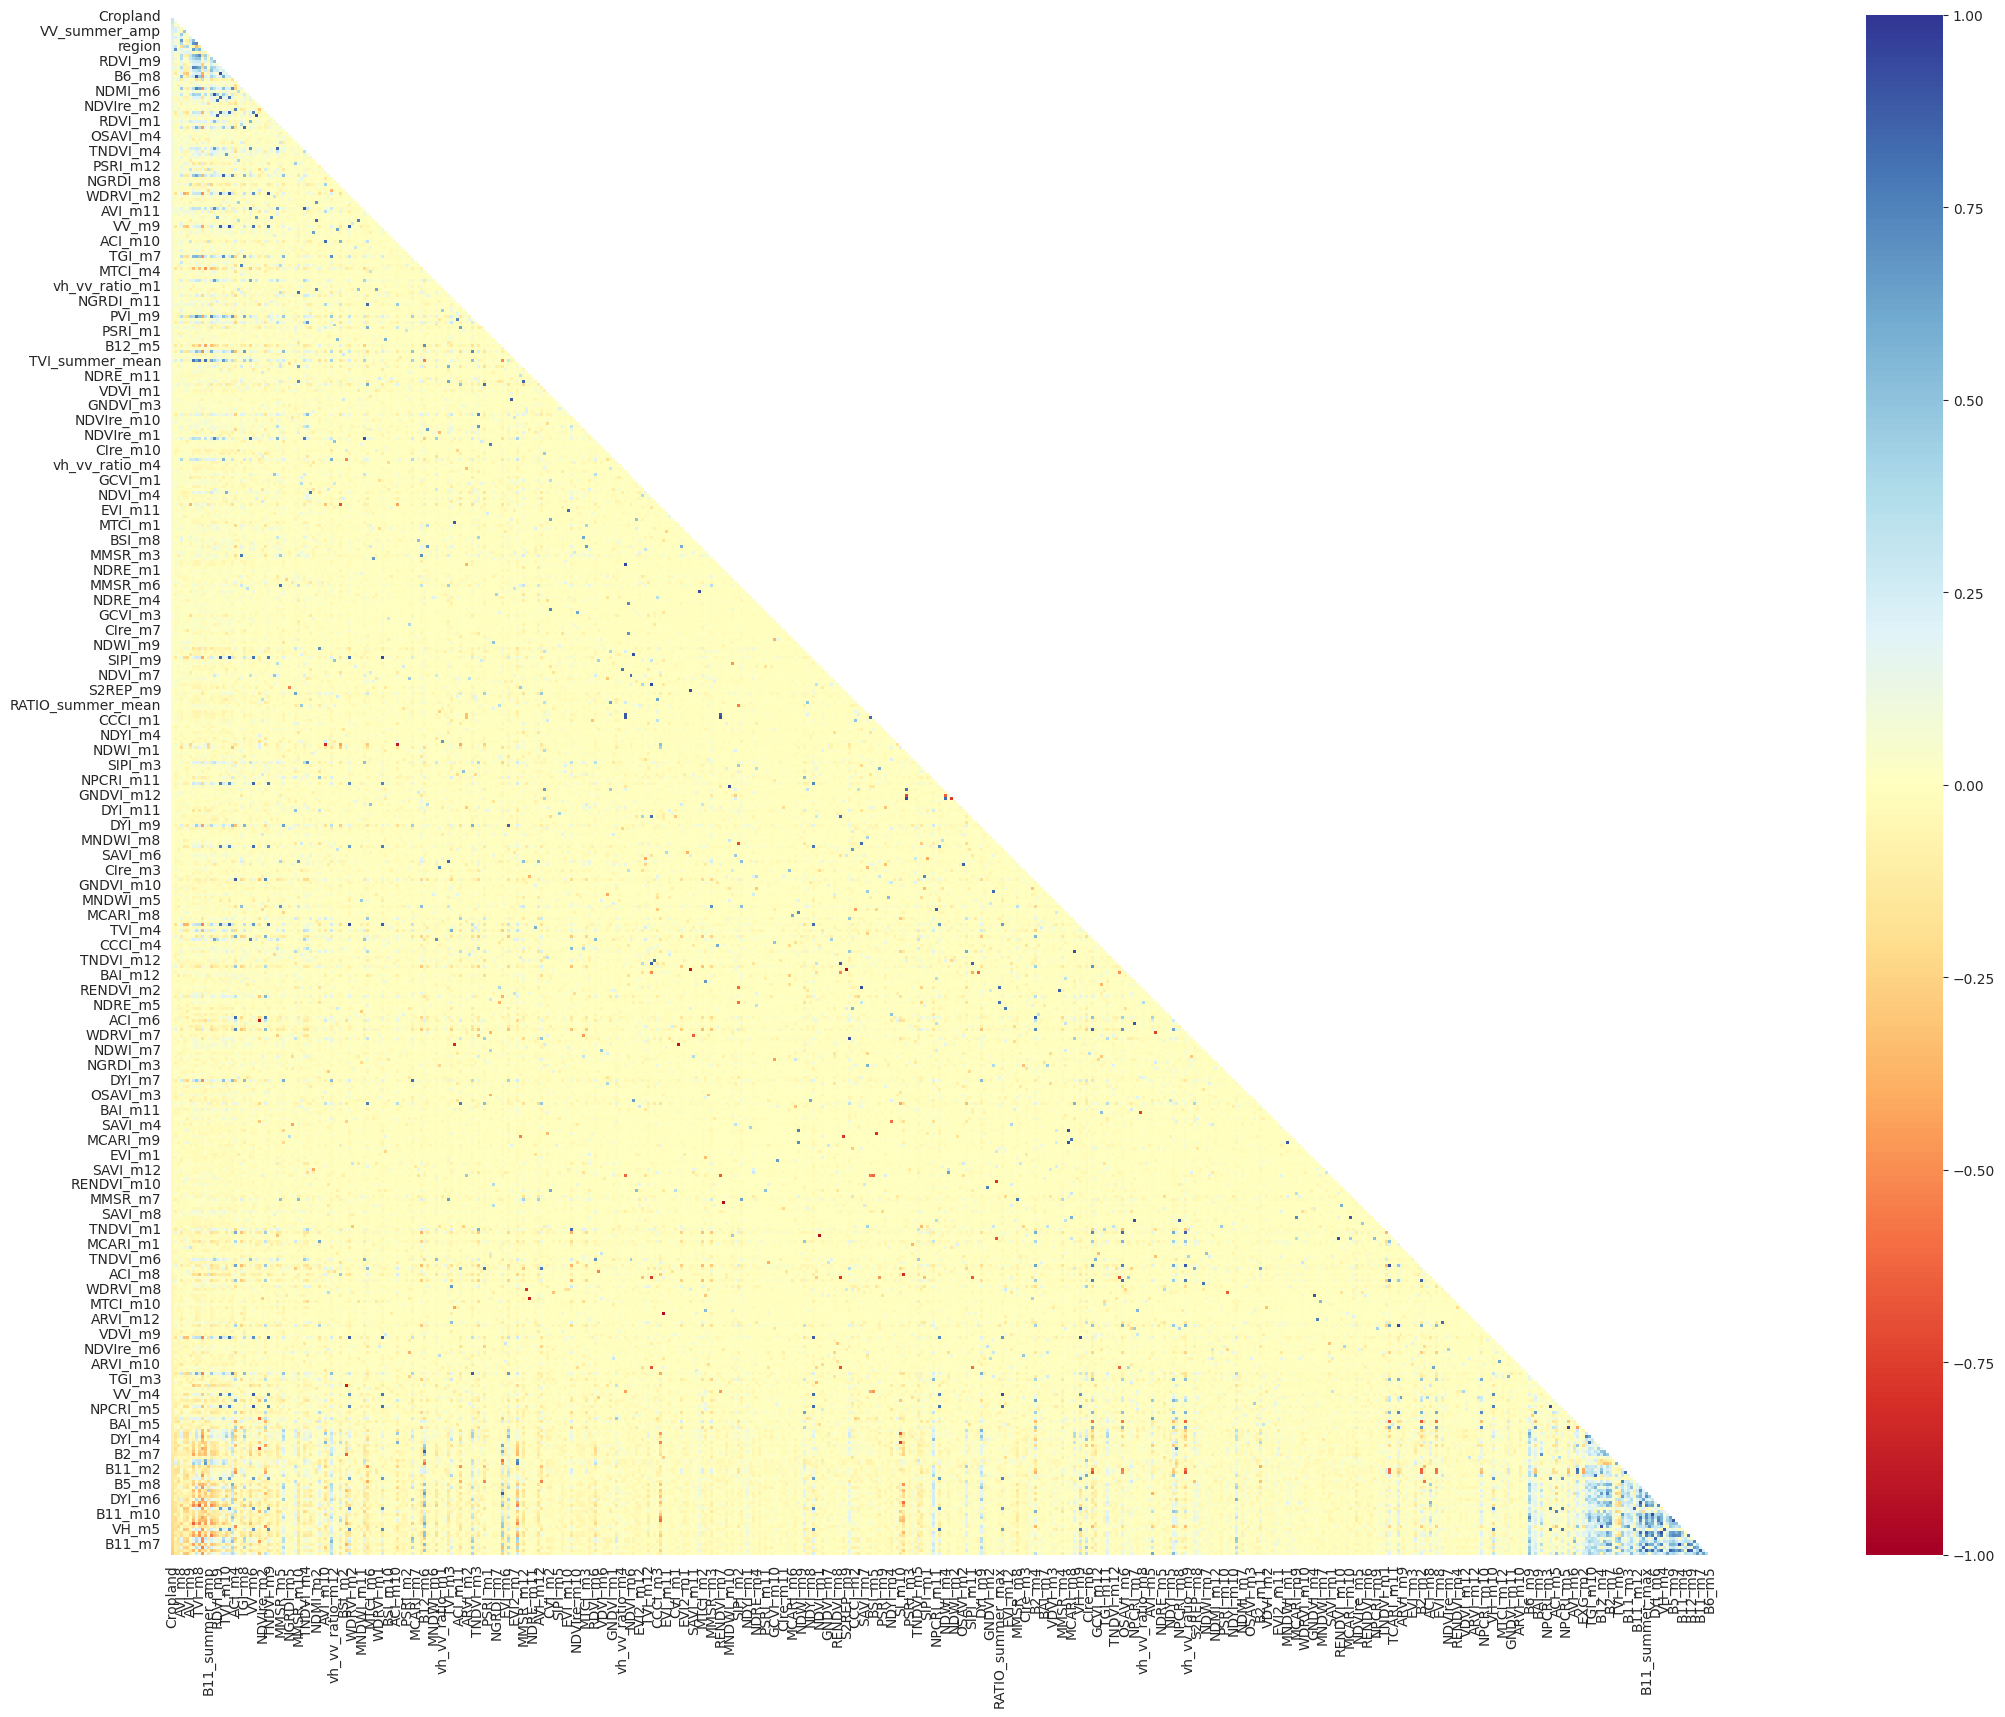

In [75]:
correlation_map(wide_train1, 'Cropland', nr_features)

In [76]:
wide_train1.groupby(['region','Cropland'])['Cropland'].count()

region  Cropland
0       0           393
        1           107
1       0           310
        1           190
Name: Cropland, dtype: int64

## SAVE FINAL DATASETS

In [77]:
#save the two datasets
wide_train1.to_csv(DATA_PATH + "Modelling_data/train_data.csv",index=False)
wide_test.to_csv(DATA_PATH + "Modelling_data/test_data.csv",index=False)

In [78]:
#log time
endtime = time.time()

In [79]:
print("Total time taken : ", (endtime-starttime)/60 ,"minutes")

Total time taken :  1.322868041197459 minutes
